In [27]:
from qsopt import * 
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
import jax
import qutip

print(f"JAX version: {jax.__version__}")
print(f"QuTiP version: {qutip.__version__}")

JAX version: 0.4.35
QuTiP version: 5.2.2


## Define experimental parameters

In [28]:
inverse_pulse_width = 1
gm = 15 * inverse_pulse_width
n_qubits = 1

# Define custom physical constants
custom_constants = PhysicalConstants(
    chi = 0.5 * gm,                    # Dispersive coupling
    photon_cavity_coupling = gm,  # Photon-cavity coupling
    inverse_pulse_width = inverse_pulse_width      # Inverse pulse width
)

# Define custom system dimensions
custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

# Define measurement protocol
custom_measurement = MeasurementProtocol(
    measurement_times=list(np.array([-8.0, 8.0])/inverse_pulse_width) 
)

# Define initial state configuration (SINGLE_PHOTON)
initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

# Define noise configuration
noise_config = NoiseConfiguration(
    depolarizing = 0.000,  
    dephasing = 0.000,      
    relaxation = 0.000
)

# Create parameters with custom configuration
exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

print(exp_parameters)

SYSTEM DIMENSIONS
  Number of qubits:          1
  Cavity levels:             2
  Qubit levels:         [2]
  Field levels:              2
  Total dimension:           8
PHYSICAL CONSTANTS
  Chi:                  [7.5]
  Photon cavity coupling: 15.0000
  Inverse pulse width:    1.0000
  Qubit interactions:   None
MEASUREMENT PROTOCOL
  Mode:                 Explicit list
  Number of measurements:      2
  Measurement times:    [-8.0, 8.0]
INITIAL STATE
  Type:                 single_photon
NOISE MODEL
  Depolarizing rate:    [0.0]
  Dephasing rate:       [0.0]
  Relaxation rate:      [0.0]
  Custom operators:     None
SYSTEM STATUS
  Configuration:        VALID


## Optional, plot pulse shape

Pulse shape plot saved to: results/pulse_shape.png


C:\Users\User\AppData\Local\Temp\ipykernel_17900\2894009835.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


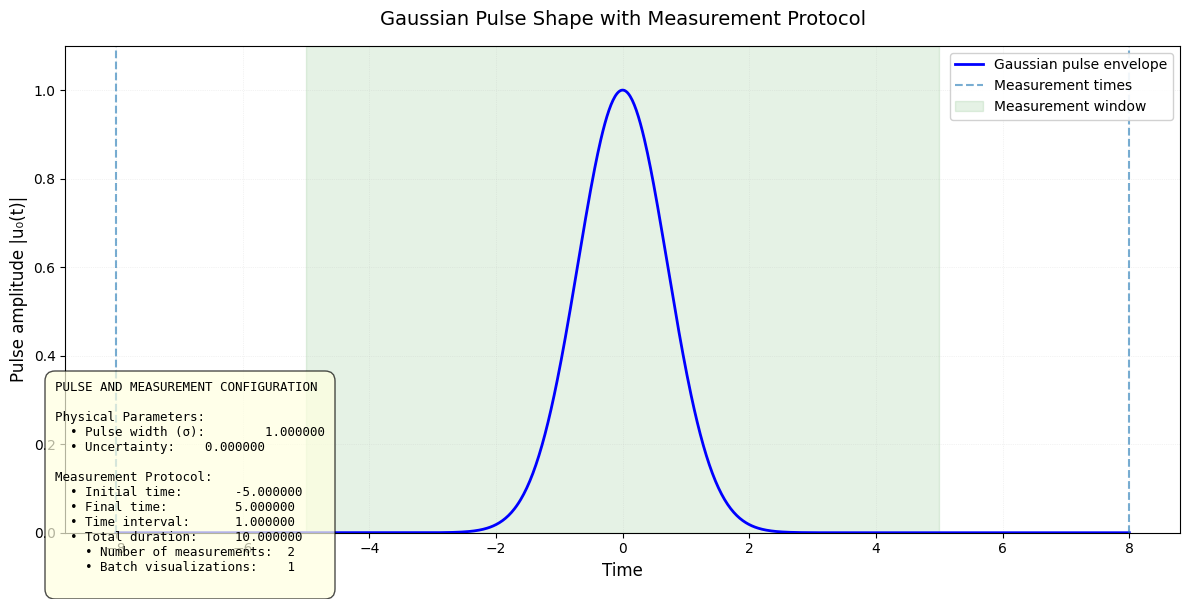

In [29]:
from qsopt.utils.visualization import plot_pulse_shape_with_measurements

fig = plot_pulse_shape_with_measurements(
    exp_params=exp_parameters,
    save_path='results/pulse_shape.png',
    batch_size=1
)
fig.show()

## Define quantum circuits

The new interface uses `QuantumCircuit` objects to define the gates applied before and after evolution. 

For the default RY protocol, we can simply use `None` (will auto-create RY circuits) or explicitly create them:

In [30]:
from qsopt.core.circuit import create_ry_circuit
initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])#, trainable=False)
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

# The circuits contain trainable parameters that will be optimized
print(f"Initial circuit parameters: {initial_circuit.get_trainable_parameters()}")
print(initial_circuit)
print(f"Final circuit parameters: {final_circuit.get_trainable_parameters()}")
print(final_circuit)

Initial circuit parameters: [Array(1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=1.5708)
Final circuit parameters: [Array(-1.57079633, dtype=float64)]
QuantumCircuit(1 qubits, 1 gates)
  0: RY[0](param=-1.5708)


## Define experiment

In [31]:
detection_metric = DetectionMetric(n_qubits=1, detection_criterion = 'fidelity')

experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
    detection_metric=detection_metric
)

experiment_base = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit)

## Test Single Simulation

In [32]:
results = experiment.run_simulation(debug=True)
print(results)


Debug times for each step:
initialize_solvers               :  0.098092
get_measurements                 :  0.000051
get_circuits                     :  0.010936
start_measurement_loop           :  0.000004
start_simulation_with0           :  0.000007
load_cached_parameters0          :  0.000010
start_simulation0                :  0.000198
measurement0:solver_0            :  1.756453
measurement0:measure_0           :  0.043426
returning_simulation0            :  0.000031
start_simulation_no0             :  0.000005
load_cached_parameters0          :  0.000011
start_simulation0                :  0.000149
measurement0:solver_0            :  1.102679
measurement0:measure_0           :  0.000243
returning_simulation0            :  0.000025
compute_probs                    :  0.000214
save_callback                    :  0.000893

Tempo totale di simulazione = 3.0134265422821045


MODE: Single Simulation
  Current Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
   

## Time Evolution

In [33]:
'''result = experiment.time_evolution(n_points=300, with_interaction=True)
print(result)

from qsopt.utils.visualization import plot_time_evolution
plot_time_evolution(
    evolution_data=result,
    show_pulse=True,
    show_measurements=True,
    show_cavity_population=True,  # Cavity population (purple)
    show_field_population=True,   # External field population (brown)
    title='Single Qubit Evolution',
    figsize=(10, 6)
)
plt.show()'''

"result = experiment.time_evolution(n_points=300, with_interaction=True)\nprint(result)\n\nfrom qsopt.utils.visualization import plot_time_evolution\nplot_time_evolution(\n    evolution_data=result,\n    show_pulse=True,\n    show_measurements=True,\n    show_cavity_population=True,  # Cavity population (purple)\n    show_field_population=True,   # External field population (brown)\n    title='Single Qubit Evolution',\n    figsize=(10, 6)\n)\nplt.show()"

## Run Optimization

In [34]:
import optax

# The experiment automatically uses its built-in callback (saves every epoch by default)
history = experiment.optimize_rotations(
    initial_values=[1.3, -1.0],
    num_steps=50,
    verbose=True,
    verbose_step=20,
    batch_size=1,
    tolerance=1e-7,
    optimizer=optax.sgd(learning_rate=0.5)
)

Configuration:
    Max iterations: 50
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection criterion: fidelity
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.300  rad (74.5°)
        param1.  reset_RY[0]  = -1.000 rad (-57.3°)
Step  setup0_RY[0]   reset0_RY[0]   Contrast    Grad Norm   Time
---------------------------------------------------------------------------
0     1.300000       -1.000000      0.815964    7.10e-01    11.47   
10    1.570796       -1.000000      0.911527    4.20e-08    4.22    
Final gradient norm: 4.20e-08
Best sensing contrast: 0.911527
Best parameters:
    param0. setup_RY[0](param=1.5708)=1.571 rad (90.0°)
    param1. reset_RY[0](param=-1.0000)=-1.000 rad (-57.3°)


In [35]:
print(history)

MODE: Optimization
     Total iterations: 11
     Best epoch:        11
     Converged: True
     Final gradient norm: 4.204419e-08
  Best Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.000000 rad (-57.30°)
  Detection Probabilities:
     P(with photon):    0.911527
     P(without photon): 0.000000
     Contrast:          0.911527


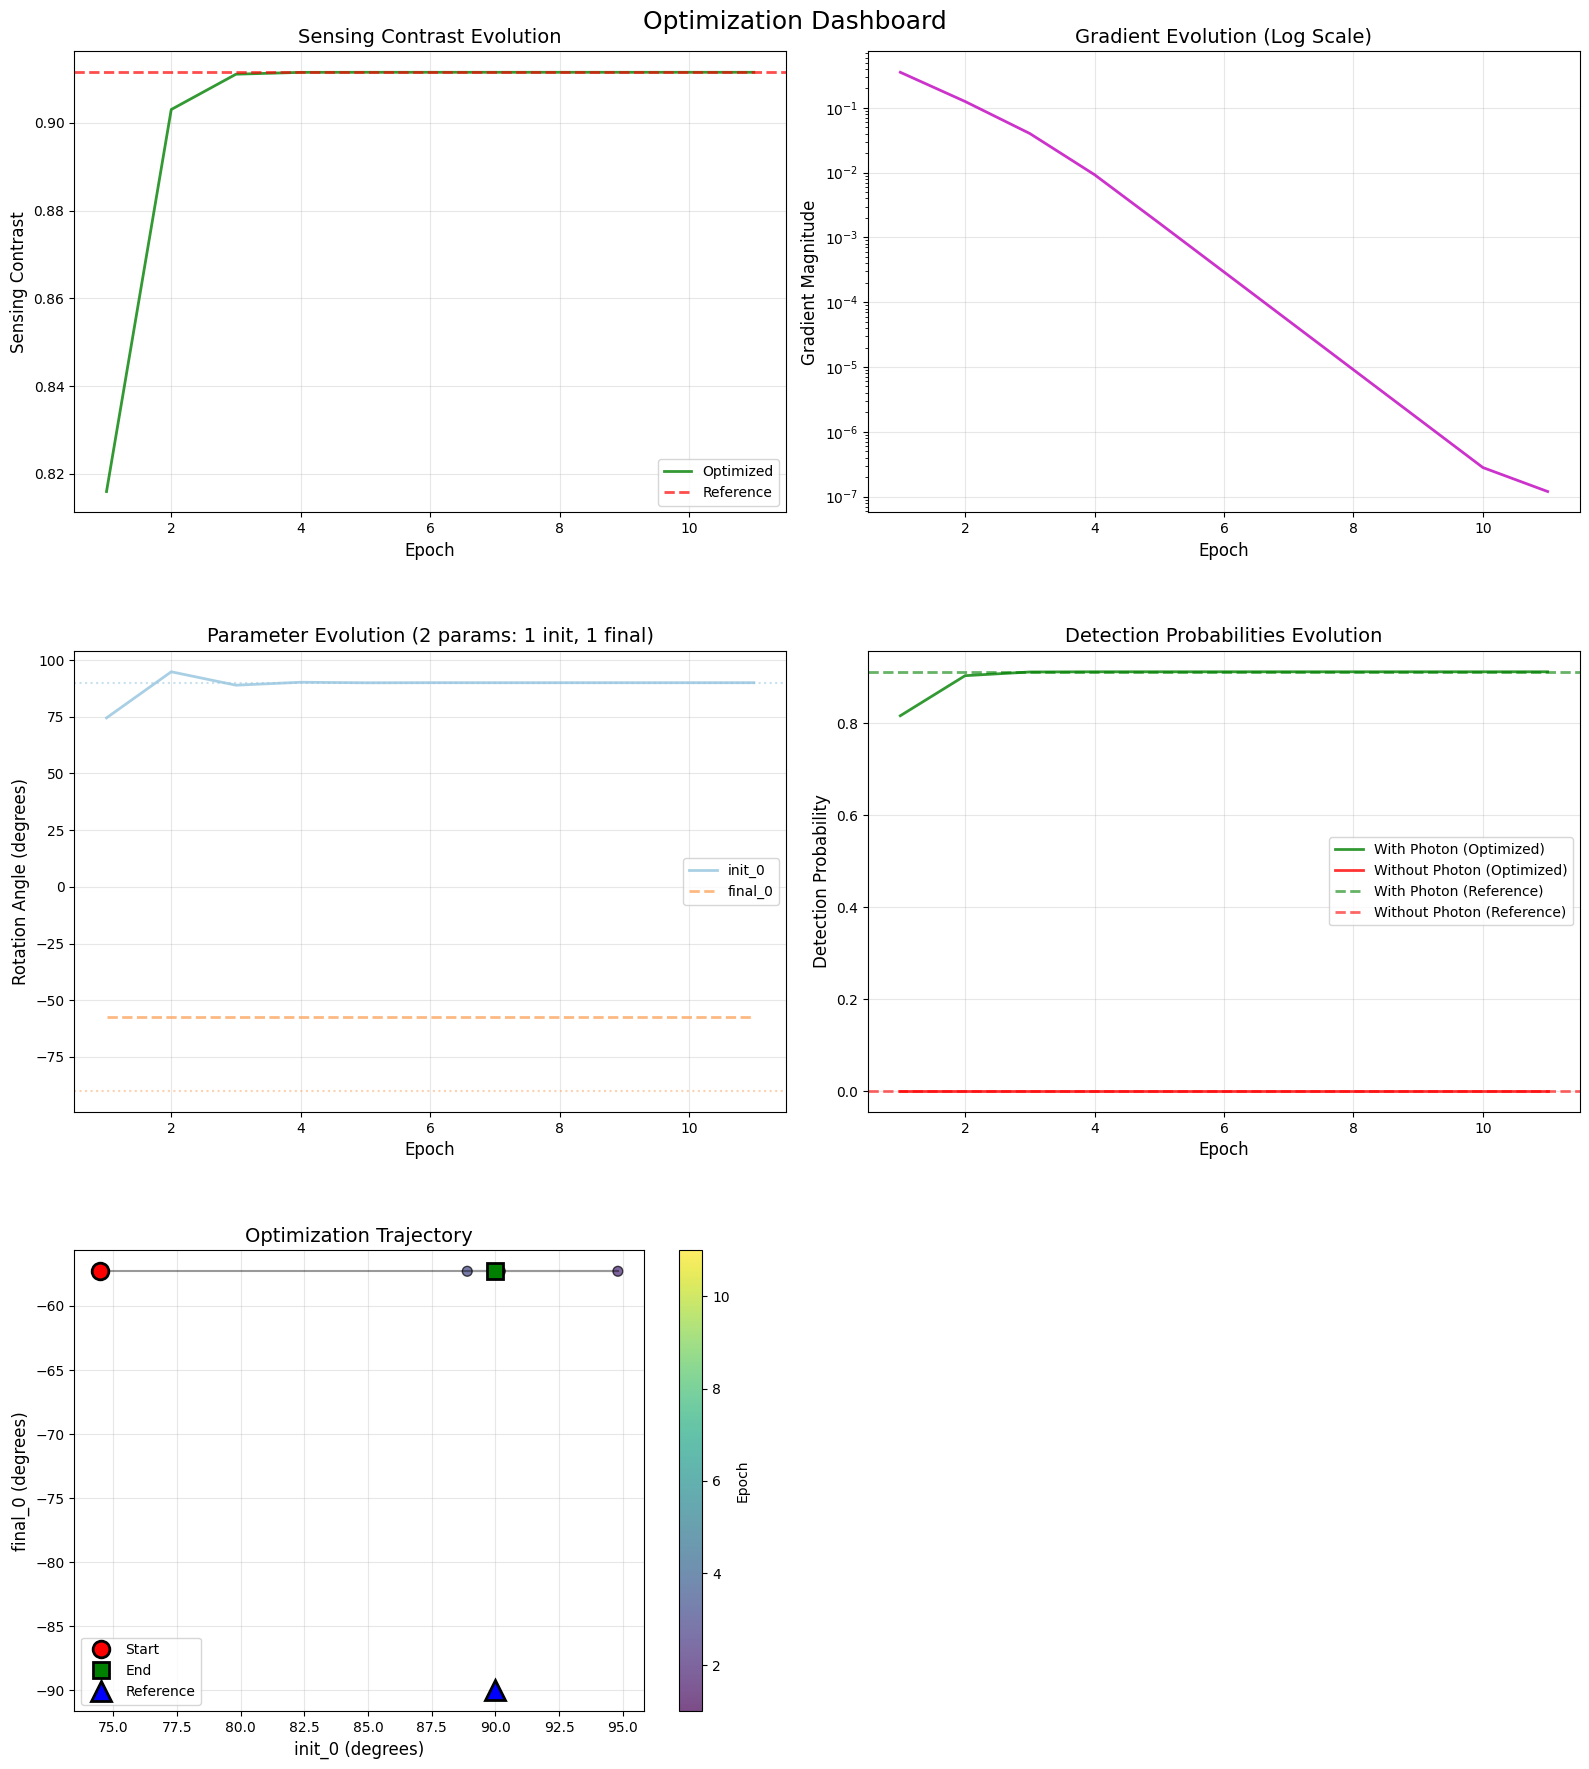

In [36]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_probabilities=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

In [37]:
import optax

# The experiment automatically uses its built-in callback (saves every epoch by default)
history = experiment_base.optimize_rotations(
    initial_values=[1.3, -1.0],
    num_steps=50,
    verbose=True,
    verbose_step=20,
    batch_size=1,
    tolerance=1e-7,
    optimizer=optax.sgd(learning_rate=0.5)
)

Configuration:
    Max iterations: 50
    Batch size: 1
    Convergence tolerance: 1.00e-07
    Detection criterion: any excited
    Trainable parameters: 2 (1 initial circuit + 1 final circuit)
    Initial parameter values:
        param0.  setup_RY[0]  = 1.300  rad (74.5°)
        param1.  reset_RY[0]  = -1.000 rad (-57.3°)
Step  setup0_RY[0]   reset0_RY[0]   Contrast    Grad Norm   Time
---------------------------------------------------------------------------
0     1.300000       -1.000000      0.810758    5.67e-01    12.14   
20    1.570796       -1.570796      0.999941    6.96e-07    8.35    
23    1.570796       -1.570796      0.999941    8.70e-08    1.26    
Final gradient norm: 8.70e-08
Best sensing contrast: 0.999941
Best parameters:
    param0. setup_RY[0](param=1.5708)=1.571 rad (90.0°)
    param1. reset_RY[0](param=-1.5708)=-1.571 rad (-90.0°)


In [38]:
print(history)

MODE: Optimization
     Total iterations: 24
     Best epoch:        24
     Converged: True
     Final gradient norm: 8.699587e-08
  Best Parameters:
     Initial circuit:
        param_0: 1.570796 rad (90.00°)
     Final circuit:
        param_0: -1.570796 rad (-90.00°)
  Detection Probabilities:
     P(with photon):    0.999941
     P(without photon): 0.000000
     Contrast:          0.999941


## Visualization Dashboard

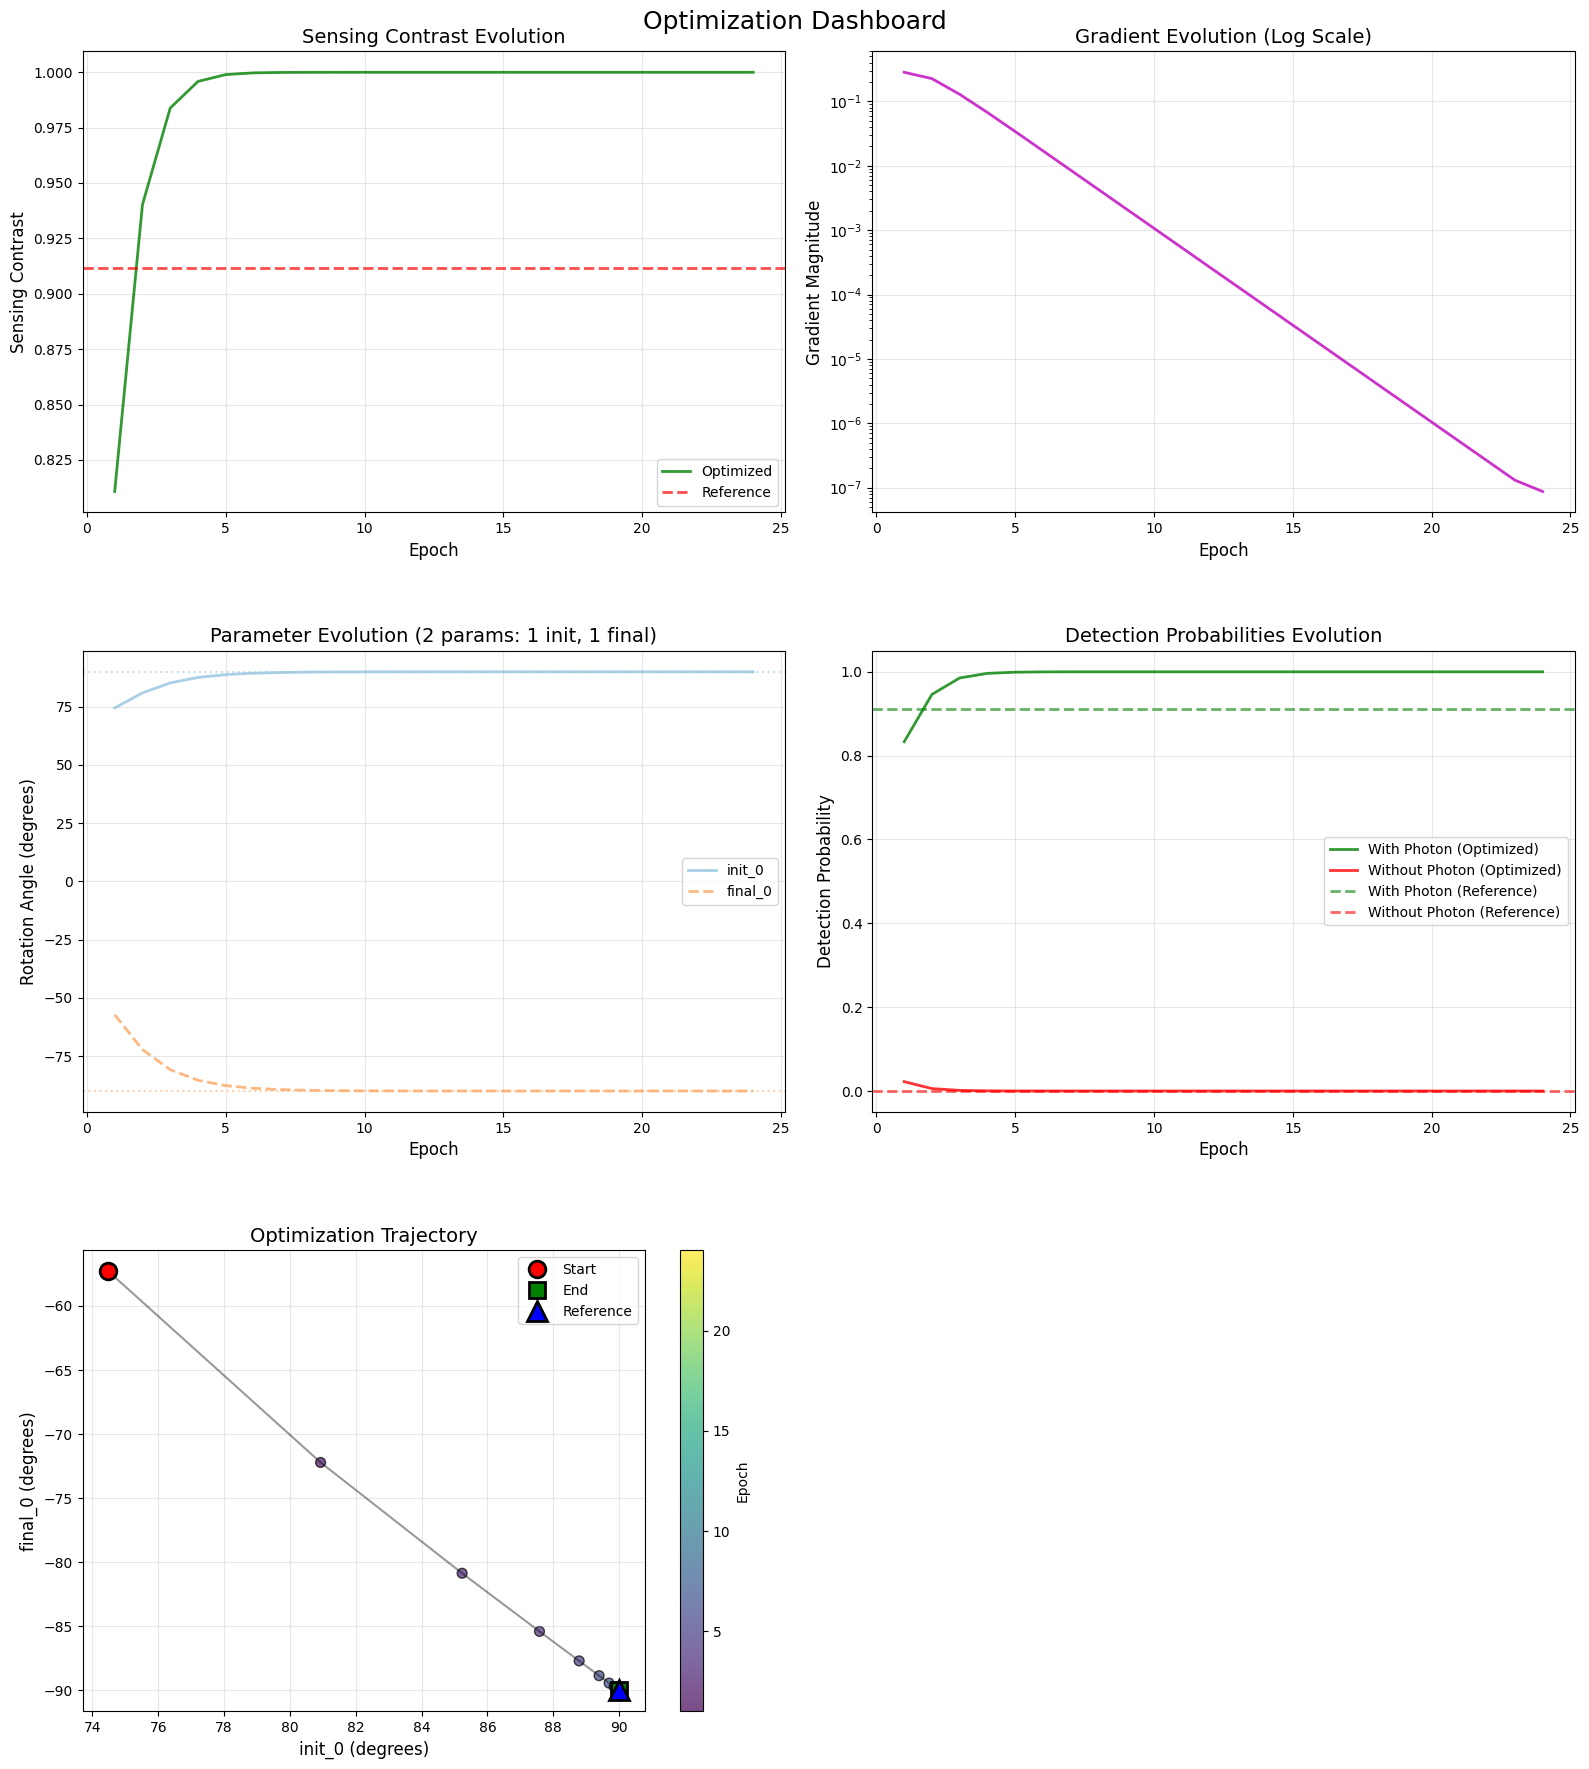

In [39]:
from qsopt.utils.visualization import plot_optimization_dashboard

# Create comprehensive dashboard with all plots enabled
fig = plot_optimization_dashboard(
    optimization_callback=history,
    reference_callback=results,
    show_contrast=True,
    show_gradients=True,
    show_parameters=True,
    show_probabilities=True,
    show_trajectory=True,
    save_path='results/rotations_opt_dashboard.pdf'  # Save to file
)

plt.show()

## Optimize Measurement Times

In [40]:
time_callback = experiment.optimize_measurement_times(batch_size=1, mode='discrete', verbose=True)

Computing time interval landscape (mode: discrete)...
  Circuit parameters: θ_init=90.0°, θ_final=-90.0°
  Resolution: 50 points
  Batch size: 1 realizations
  Total evolution time: 10.0000
  Progress: 100.0% (interval=10.0000, n_meas=2, contrast=0.911527)
Completed in 30.6s (0.612s per point)
  Optimal interval: 10.0000 (n_meas=2, contrast=0.911527)

Optimization complete:
  Best interval: 10.0000
  Best contrast: 0.911527
  Number of measurements: 2


Time interval landscape plot saved to: results/time_interval_opt.pdf


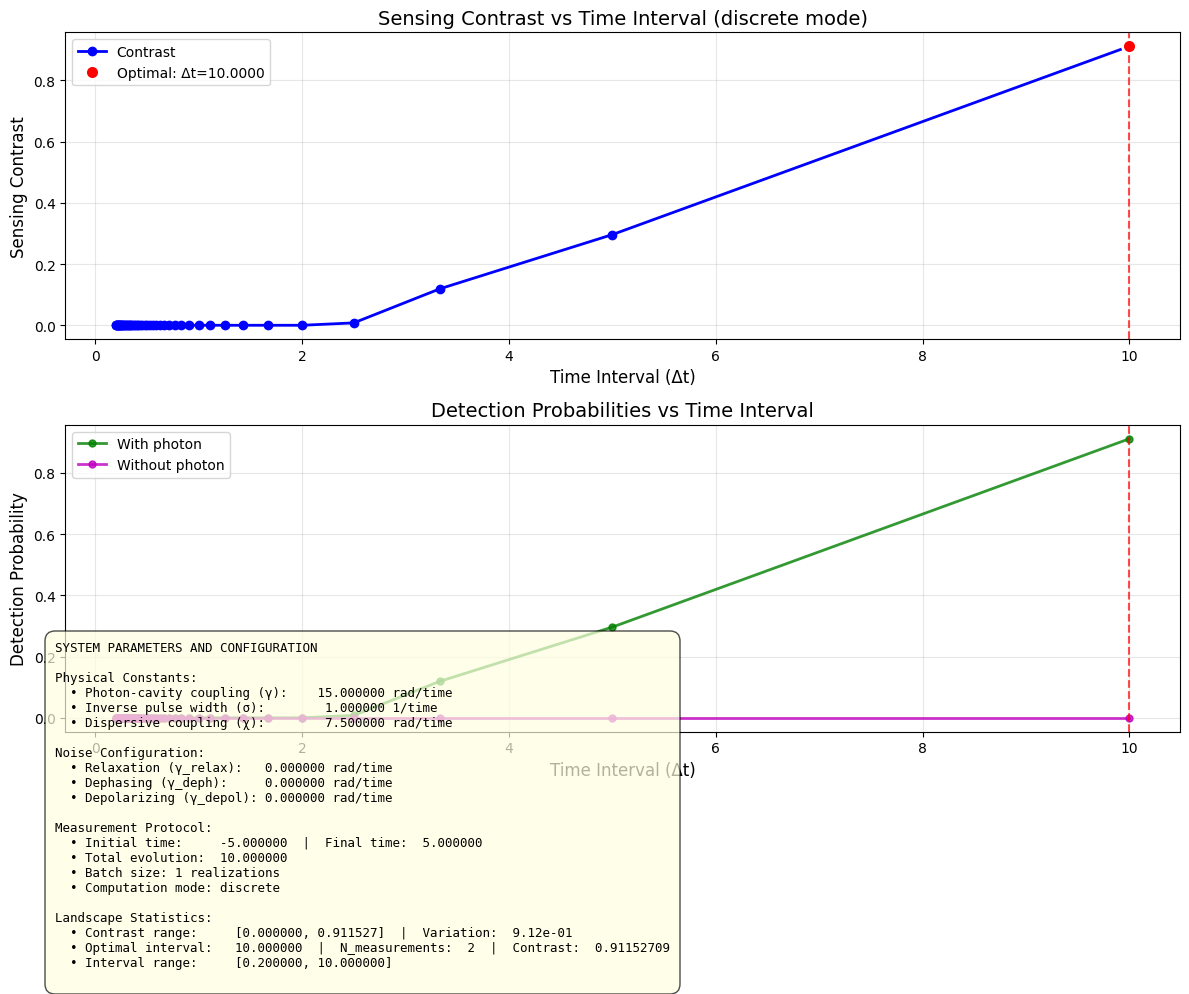

In [41]:
from qsopt.utils.visualization import plot_time_interval_landscape

fig = plot_time_interval_landscape(
    landscape_data=time_callback,
    exp_params=experiment.experimental_params,
    save_path='results/time_interval_opt.pdf'
)


## Sweep chi-gamma

In [42]:
results_sweep = experiment.sweep_chi_gamma(
    chi_interval=[1.0, 30.0],
    gamma_interval=[1.0, 60.0],
    resolution_chi=10,
    resolution_gamma=10,
    chi_scale='linear',
    gamma_scale='linear',
    batch_size=1,
    verbose=True
)

Computing χ-γ parameter sweep...
  Resolution: 10×10 = 100 points
  χ range: [1.00, 30.00] (linear scale)
  γ range: [1.00, 60.00] (linear scale)
  Progress: 10.0% | Elapsed: 26.1s
  Progress: 20.0% | Elapsed: 51.6s
  Progress: 30.0% | Elapsed: 79.4s
  Progress: 40.0% | Elapsed: 105.0s
  Progress: 50.0% | Elapsed: 133.3s
  Progress: 60.0% | Elapsed: 159.1s
  Progress: 70.0% | Elapsed: 179.2s
  Progress: 80.0% | Elapsed: 217.5s
  Progress: 90.0% | Elapsed: 253.0s
  Progress: 100.0% | Elapsed: 287.0s
Sweep completed in 287.0s
  Max contrast: 0.911574
  Optimal χ: 30.000
  Optimal γ: 60.000


SweepResults:
  Parameter 1: gamma
    Interval: [1, 60]
    Scale: linear
    Resolution: 10 points
  Parameter 2: chi
    Interval: [1, 30]
    Scale: linear
    Resolution: 10 points
  Available results: contrast_map, detection_map, detection_without_map
  Optimal point: chi=30, gamma=60


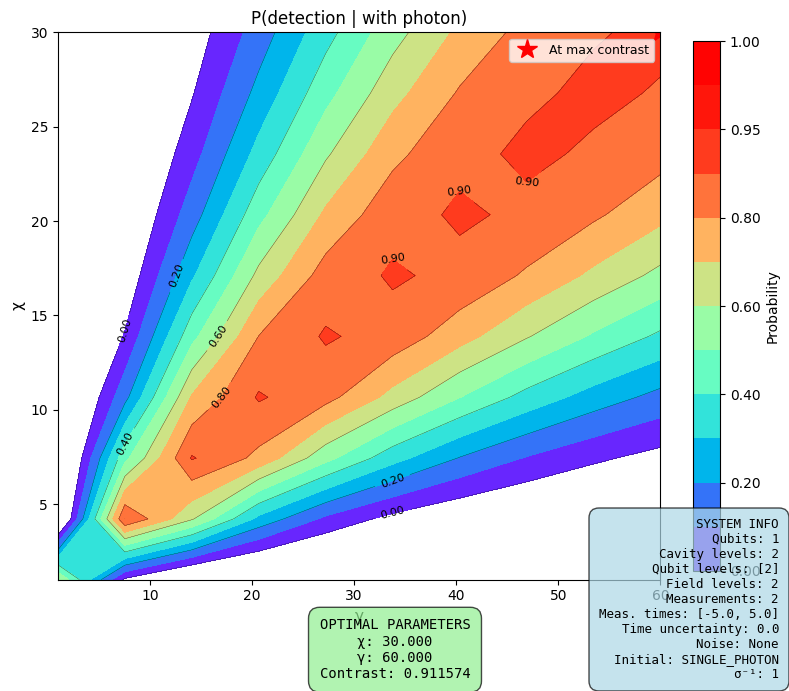

In [43]:
from qsopt.utils.visualization import plot_sweep_results

print(results_sweep)

plot_sweep_results(
    results_sweep,
    results_to_plot=['detection_map'],
    figsize=(8, 7)
)
plt.show()

## Performance Profiling

Testing the performance of different components of the Experiment class

In [44]:
import time

profiling_results = {}

print("="*80)
print("1. PROFILING EXPERIMENT INITIALIZATION")
print("="*80)

# Reset to initial parameters for consistent testing
gm = 0.03 * 2 * np.pi
inverse_pulse_width = 0.1 * gm

custom_constants = PhysicalConstants(
    chi = 0.5 * gm,
    photon_cavity_coupling = gm,
    inverse_pulse_width = 0.1 * gm
)

custom_dims = SystemDimensions(
    cavity_levels=2,
    qubit_levels=2,
    field_levels=2
)

custom_measurement = MeasurementProtocol(
    measurement_times = None,
    initial_time=-8.0/inverse_pulse_width,
    final_time=8.0/inverse_pulse_width,
    time_interval=8.0/inverse_pulse_width,
    initial_time_uncertainty=.0/inverse_pulse_width
)

initial_state = InitialStateConfig(
    state_type=InitialStateType.SINGLE_PHOTON
)

noise_config = NoiseConfiguration(
    depolarizing = 0.000,
    dephasing = 0.000,
    relaxation = 0.000
)

exp_parameters = ExperimentalParameters(
    physical_constants=custom_constants,
    system_dims=custom_dims,
    measurement=custom_measurement,
    initial_state=initial_state,
    noise_config=noise_config
)

# Time circuit creation
t0 = time.perf_counter()
initial_circuit = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])
final_circuit = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])
t1 = time.perf_counter()
profiling_results["circuit_creation_ms"] = (t1 - t0) * 1000
print(f"\n✓ Circuit creation: {profiling_results['circuit_creation_ms']:.2f} ms")

# Time experiment initialization
t0 = time.perf_counter()
test_experiment = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
)
t1 = time.perf_counter()
profiling_results["experiment_initialization_ms"] = (t1 - t0) * 1000
print(f"✓ Experiment initialization: {profiling_results['experiment_initialization_ms']:.2f} ms")

1. PROFILING EXPERIMENT INITIALIZATION

✓ Circuit creation: 2.29 ms
✓ Experiment initialization: 586.02 ms


In [45]:
print("\n" + "="*80)
print("2. PROFILING CIRCUIT UNITARY COMPUTATION")
print("="*80)

# Clear cache to test cold start
test_experiment._cached_circuit_unitaries = None

# Time first call (includes computation)
t0 = time.perf_counter()
unitaries = test_experiment._prepare_circuit_unitaries()
t1 = time.perf_counter()
first_unitary_ms = (t1 - t0) * 1000
profiling_results["unitary_prepare_first_ms"] = first_unitary_ms
print(f"\n✓ First call (compute + cache): {first_unitary_ms:.2f} ms")

# Time second call (from cache)
t0 = time.perf_counter()
unitaries = test_experiment._prepare_circuit_unitaries()
t1 = time.perf_counter()
second_unitary_ms = (t1 - t0) * 1000
profiling_results["unitary_prepare_cached_ms"] = second_unitary_ms
print(f"✓ Second call (from cache): {second_unitary_ms:.4f} ms")

if second_unitary_ms > 0.001:
    speedup = first_unitary_ms / second_unitary_ms
    print(f"  -> Caching speedup: {speedup:.1f}x")
else:
    print("  -> Caching speedup: effectively instantaneous")


2. PROFILING CIRCUIT UNITARY COMPUTATION

✓ First call (compute + cache): 18.82 ms
✓ Second call (from cache): 10.7013 ms
  -> Caching speedup: 1.8x


In [46]:
print("\n" + "="*80)
print("3. PROFILING SINGLE SIMULATION")
print("="*80)

# Time complete simulation
t0 = time.perf_counter()
results_test = test_experiment.run_simulation(batch_size=1)
t1 = time.perf_counter()
run_simulation_first_ms = (t1 - t0) * 1000
profiling_results["run_simulation_first_ms"] = run_simulation_first_ms
print(f"\n✓ Complete run_simulation: {run_simulation_first_ms:.2f} ms")

# Break down simulation components
print("\n--- Breaking down simulation components ---")

rho0 = test_experiment._cached_initial_state
solver_with = test_experiment.get_solver_with_interaction()
solver_without = test_experiment.get_solver_no_interaction()
measurement_times = test_experiment.experimental_params.get_measurement_times_with_uncertainty(1)
circuit_unitaries = test_experiment._prepare_circuit_unitaries()

# Time single evolution (with photon)
t0 = time.perf_counter()
prob_with = test_experiment.simulation(
    solver=solver_with,
    rho=rho0,
    measurements=measurement_times,
    precomputed_unitaries=circuit_unitaries,
)
t1 = time.perf_counter()
evolution_with_ms = (t1 - t0) * 1000
profiling_results["evolution_with_photon_ms"] = evolution_with_ms
print(f"  ✓ Evolution WITH photon: {evolution_with_ms:.2f} ms")

# Time single evolution (without photon)
t0 = time.perf_counter()
prob_without = test_experiment.simulation(
    solver=solver_without,
    rho=rho0,
    measurements=measurement_times,
    precomputed_unitaries=circuit_unitaries,
)
t1 = time.perf_counter()
evolution_without_ms = (t1 - t0) * 1000
profiling_results["evolution_without_photon_ms"] = evolution_without_ms
print(f"  ✓ Evolution WITHOUT photon: {evolution_without_ms:.2f} ms")


3. PROFILING SINGLE SIMULATION

✓ Complete run_simulation: 3646.17 ms

--- Breaking down simulation components ---
  ✓ Evolution WITH photon: 117.65 ms
  ✓ Evolution WITHOUT photon: 20.94 ms


In [47]:
print("\n" + "="*80)
print("4. PROFILING TIME EVOLUTION")
print("="*80)

time_evolution_ms = {}

# Test with different numbers of points
for n_points in [50, 100, 200, 300]:
    t0 = time.perf_counter()
    result_evol = test_experiment.time_evolution(n_points=n_points, with_interaction=True)
    t1 = time.perf_counter()
    elapsed_ms = (t1 - t0) * 1000
    time_evolution_ms[n_points] = elapsed_ms
    print(f"\n✓ Time evolution ({n_points:3d} points): {elapsed_ms:6.2f} ms ({elapsed_ms/n_points:5.2f} ms/point)")

profiling_results["time_evolution_ms"] = time_evolution_ms


4. PROFILING TIME EVOLUTION

✓ Time evolution ( 50 points): 2205.93 ms (44.12 ms/point)

✓ Time evolution (100 points): 1045.19 ms (10.45 ms/point)

✓ Time evolution (200 points): 2134.33 ms (10.67 ms/point)

✓ Time evolution (300 points): 2990.41 ms ( 9.97 ms/point)


In [48]:
print("\n" + "="*80)
print("5. PROFILING OPTIMIZATION")
print("="*80)

# Test single optimization step
t0 = time.perf_counter()
history_test = test_experiment.optimize_rotations(
    initial_values=[1.3, -1.0],
    num_steps=10,
    verbose=False,
    batch_size=1,
    tolerance=1e-10,  # Won't converge, just test speed
    optimizer=optax.sgd(learning_rate=0.5)
)
t1 = time.perf_counter()

optimization_total_ms = (t1 - t0) * 1000
optimization_step_ms = optimization_total_ms / 10
profiling_results["optimization_10_steps_ms"] = optimization_total_ms
profiling_results["optimization_step_ms"] = optimization_step_ms
print(f"\n✓ 10 optimization steps: {optimization_total_ms:.2f} ms")
print(f"✓ Average per step: {optimization_step_ms:.2f} ms")

print("\n" + "="*80)
print("PROFILING SUMMARY")
print("="*80)
print("\nRun the next summary cell to generate metrics from the measured values.")


5. PROFILING OPTIMIZATION

✓ 10 optimization steps: 19277.24 ms
✓ Average per step: 1927.72 ms

PROFILING SUMMARY

Run the next summary cell to generate metrics from the measured values.


In [49]:
print("\n" + "="*80)
print("6. PROFILING SECOND RUN (after JIT compilation)")
print("="*80)

# Run a second simulation to see if it's faster (should be after JAX compilation)
t0 = time.perf_counter()
results_test2 = test_experiment.run_simulation(batch_size=1)
t1 = time.perf_counter()
run_simulation_second_ms = (t1 - t0) * 1000
profiling_results["run_simulation_second_ms"] = run_simulation_second_ms
print(f"\n✓ Second run_simulation: {run_simulation_second_ms:.2f} ms")

first_run_ms = profiling_results.get("run_simulation_first_ms")
if first_run_ms is not None and run_simulation_second_ms > 0:
    speedup = first_run_ms / run_simulation_second_ms
    profiling_results["jit_speedup_factor"] = speedup
    print(f"  -> Speedup vs first run: {speedup:.1f}x faster")
else:
    print("  -> Speedup not available (run the first simulation profiling cell first).")


6. PROFILING SECOND RUN (after JIT compilation)

✓ Second run_simulation: 177.01 ms
  -> Speedup vs first run: 20.6x faster


In [50]:
print("\n" + "="*80)
print("7. TESTING FIXED CACHE (reload module first)")
print("="*80)

# Reload the module to get the fixed version
import importlib
import qsopt.core.experiment.experiment as exp_module
importlib.reload(exp_module)
from qsopt.core.experiment import Experiment

# Create new experiment with fixed code
test_experiment_fixed = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=initial_circuit,
    final_circuit=final_circuit,
)

# Clear cache to test cold start
test_experiment_fixed._cached_circuit_unitaries = None

# Time first call (should compute + cache)
t0 = time.perf_counter()
unitaries = test_experiment_fixed._prepare_circuit_unitaries()
t1 = time.perf_counter()
print(f"\n✓ First call (compute + cache): {(t1-t0)*1000:.2f} ms")

# Time second call (should return from cache immediately)
t0 = time.perf_counter()
unitaries = test_experiment_fixed._prepare_circuit_unitaries()
t1 = time.perf_counter()
print(f"✓ Second call (from cache): {(t1-t0)*1000:.4f} ms")

if (t1-t0)*1000 < 0.1:
    print("  → ✓ CACHE WORKING! Near-instant return")
else:
    print(f"  → ⚠ Cache not working properly, still takes {(t1-t0)*1000:.2f}ms")


7. TESTING FIXED CACHE (reload module first)



✓ First call (compute + cache): 4.66 ms
✓ Second call (from cache): 4.2303 ms
  → ⚠ Cache not working properly, still takes 4.23ms


## Performance Summary & Recommendations

This section now uses dynamically measured values from the profiling cells instead of hardcoded constants.

Run the next code cell to generate an up-to-date summary from `profiling_results`.

In [51]:
print("\n" + "="*80)
print("DYNAMIC PERFORMANCE SUMMARY")
print("="*80)

required_keys = [
    "run_simulation_first_ms",
    "run_simulation_second_ms",
    "evolution_with_photon_ms",
    "evolution_without_photon_ms",
    "optimization_step_ms",
]

missing_keys = [k for k in required_keys if k not in profiling_results]
if missing_keys:
    print("Missing measurements. Run cells 1 to 6 before this summary cell.")
    print(f"Missing keys: {missing_keys}")
else:
    first_ms = profiling_results["run_simulation_first_ms"]
    second_ms = profiling_results["run_simulation_second_ms"]
    with_ms = profiling_results["evolution_with_photon_ms"]
    without_ms = profiling_results["evolution_without_photon_ms"]
    opt_step_ms = profiling_results["optimization_step_ms"]
    jit_speedup = first_ms / second_ms if second_ms > 0 else float("inf")

    print(f"1. First-run JIT overhead: first run = {first_ms:.2f} ms")
    print(f"   Second run = {second_ms:.2f} ms ({jit_speedup:.1f}x faster)")

    print(f"2. Post-warmup simulation performance: {second_ms:.2f} ms per run")
    print(f"   - Evolution WITH photon: {with_ms:.2f} ms")
    print(f"   - Evolution WITHOUT photon: {without_ms:.2f} ms")

    evolution_data = profiling_results.get("time_evolution_ms", {})
    if evolution_data:
        print("3. Time evolution scaling:")
        for n_points in sorted(evolution_data):
            total_ms = evolution_data[n_points]
            print(f"   - {n_points:3d} points: {total_ms/n_points:.2f} ms/point")

    print(f"4. Optimization average cost: {opt_step_ms:.2f} ms per step")

print("\nRecommendations:")
print("1. The first run is expected to be slower because of JAX compilation.")
print("2. For benchmarking, always compare warm runs, not cold starts.")
print("3. Use medium/large grids for time-evolution to amortize setup costs.")
print("4. Keep caching enabled when sweeping parameters.")


DYNAMIC PERFORMANCE SUMMARY
1. First-run JIT overhead: first run = 3646.17 ms
   Second run = 177.01 ms (20.6x faster)
2. Post-warmup simulation performance: 177.01 ms per run
   - Evolution WITH photon: 117.65 ms
   - Evolution WITHOUT photon: 20.94 ms
3. Time evolution scaling:
   -  50 points: 44.12 ms/point
   - 100 points: 10.45 ms/point
   - 200 points: 10.67 ms/point
   - 300 points: 9.97 ms/point
4. Optimization average cost: 1927.72 ms per step

Recommendations:
1. The first run is expected to be slower because of JAX compilation.
2. For benchmarking, always compare warm runs, not cold starts.
3. Use medium/large grids for time-evolution to amortize setup costs.
4. Keep caching enabled when sweeping parameters.


In [52]:
print("="*80)
print("FINAL VERIFICATION - Testing all optimizations")
print("="*80)

# Reload modules to get latest optimizations
import importlib
import qsopt.core.circuit as circuit_module
import qsopt.core.experiment.experiment as exp_module
importlib.reload(circuit_module)
importlib.reload(exp_module)
from qsopt.core.circuit import create_ry_circuit
from qsopt.core.experiment import Experiment

# Create fresh circuits and experiment
init_circ = create_ry_circuit(n_qubits=1, theta_values=[np.pi/2])
final_circ = create_ry_circuit(n_qubits=1, theta_values=[-np.pi/2])

optimized_exp = Experiment(
    experimental_params=exp_parameters,
    initial_circuit=init_circ,
    final_circuit=final_circ,
)

print("\n1. Testing circuit unitary caching:")
# Clear cache
init_circ._cached_unitary_jax = None
init_circ._cached_unitary_qutip = None

t0 = time.perf_counter()
u1 = init_circ.get_unitary(qutip=False)
t1 = time.perf_counter()
print(f"   First call: {(t1-t0)*1000:.3f} ms")

t0 = time.perf_counter()
u2 = init_circ.get_unitary(qutip=False)
t1 = time.perf_counter()
print(f"   Second call (cached): {(t1-t0)*1000:.3f} ms")
print(f"   → Speedup: {((t1-t0)*1000) < 0.1 and '✓ Cache working!' or '⚠ Still computing'}")

print("\n2. Testing experiment-level caching:")
optimized_exp._cached_circuit_unitaries = None

t0 = time.perf_counter()
u = optimized_exp._prepare_circuit_unitaries()
t1 = time.perf_counter()
print(f"   First call: {(t1-t0)*1000:.3f} ms")

t0 = time.perf_counter()
u = optimized_exp._prepare_circuit_unitaries()
t1 = time.perf_counter()
print(f"   Second call (cached): {(t1-t0)*1000:.3f} ms")
print(f"   → Speedup: {((t1-t0)*1000) < 0.1 and '✓ Cache working!' or '⚠ Still computing'}")

print("\n3. Testing full simulation performance:")
t0 = time.perf_counter()
result = optimized_exp.run_simulation(batch_size=1)
t1 = time.perf_counter()
print(f"   First run (with JIT): {(t1-t0)*1000:.1f} ms")

t0 = time.perf_counter()
result = optimized_exp.run_simulation(batch_size=1)
t1 = time.perf_counter()
print(f"   Second run (cached): {(t1-t0)*1000:.1f} ms")

print("\n" + "="*80)
print("✓ All optimizations verified!")
print("="*80)

FINAL VERIFICATION - Testing all optimizations

1. Testing circuit unitary caching:
   First call: 2.341 ms
   Second call (cached): 0.265 ms
   → Speedup: ⚠ Still computing

2. Testing experiment-level caching:
   First call: 6.786 ms
   Second call (cached): 4.109 ms
   → Speedup: ⚠ Still computing

3. Testing full simulation performance:
   First run (with JIT): 3560.4 ms
   Second run (cached): 144.6 ms

✓ All optimizations verified!
